In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import _nb_setup

import numpy as np
import pandas as pd
import random
import time
import matplotlib.pyplot as plt
import networkx as nx
import kmapper as km
import kmapper.evaluate as evaluate
from sklearn import cluster
from kmapper import BCMO
from dyneusr.datasets import make_trefoil



In [3]:
trefoil_data = make_trefoil(size=100)
X = trefoil_data.data
y = trefoil_data.target

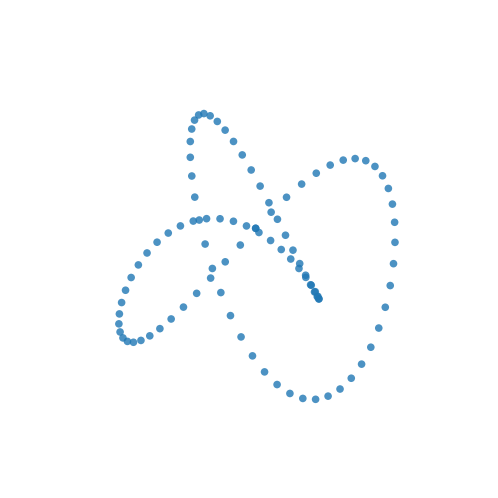

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from dyneusr.datasets import make_trefoil

trefoil_data = make_trefoil(size=100)
X = trefoil_data.data
X1 = X[:33]
X2 = X[33:66]
X3 = X[66:]

color = '#1f77b4'

# Cấu hình chung
kwargs = dict(color=color, alpha=0.8, s=30, edgecolors='none')
view_elev, view_azim = 30, 90

# Tạo figure với 4 subplots (2x2)
fig = plt.figure(figsize=(12, 10))

# Toàn bộ trefoil
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter3D(X[:, 0], X[:, 1], X[:, 2], **kwargs)
ax1.view_init(view_elev, view_azim)
ax1.set_axis_off()

# # Phần đầu
# ax2 = fig.add_subplot(2, 2, 2, projection='3d')
# ax2.scatter3D(X1[:, 0], X1[:, 1], X1[:, 2], **kwargs)
# ax2.view_init(view_elev, view_azim)
# ax2.set_axis_off()

# # Phần giữa
# ax3 = fig.add_subplot(2, 2, 3, projection='3d')
# ax3.scatter3D(X2[:, 0], X2[:, 1], X2[:, 2], **kwargs)
# ax3.view_init(view_elev, view_azim)
# ax3.set_axis_off()

# # Phần cuối
# ax4 = fig.add_subplot(2, 2, 4, projection='3d')
# ax4.scatter3D(X3[:, 0], X3[:, 1], X3[:, 2], **kwargs)
# ax4.view_init(view_elev, view_azim)
# ax4.set_axis_off()

plt.tight_layout()
plt.show()

In [5]:
X_data = X
mapper = km.D_Mapper(verbose=0)
projected_data = mapper.fit_transform(X, projection=[0])


In [ ]:
import numpy as np
import sklearn

@km.dmapper_objective
def objective_function_DMapper(n, a):
    mapper = km.D_Mapper(verbose=0)
    projected_data = mapper.fit_transform(X_data, projection=[0])
    cover = km.D_Cover(n_cubes=n, alpha=a, verbose=0, tol=12*1e-4, max_iter=3000000, n_init=100)
    graph = mapper.map(projected_data, X_data, cover=cover)
    sc_adj = evaluate.compute_SC_adj(
        X_data, projected_data, graph,
        Cover=km.D_Cover(n_cubes=n, alpha=a, verbose=0, tol=12*1e-4, max_iter=3000000, n_init=100),
        type='d',
    )
    return sc_adj


def run_bcmo_once(run_id):
    return km.run_bcmo(
        objective_fn=objective_function_DMapper,
        bounds=[(7, 9), (0.01, 0.1)],
        NP=20,
        gen=10,
        run_id=run_id,
        output="trefoil_BCMO.txt",
    )





In [7]:
def run_bcmo_once(run_id):
    return km.run_bcmo(
        objective_fn=objective_function_DMapper,
        bounds=[(7, 9), (0.01, 0.1)],
        NP=20,
        gen=10,
        run_id=run_id,
        output="trefoil_BCMO.txt",
    )

In [8]:
run_bcmo_once(1)

100%|██████████| 100/100


SC:0.010258857248348796
SC_norm:0.5051294286241744
TSR:0.16666666666666666
SC_adj:0.3358980476454205


100%|██████████| 100/100


SC:0.19994260507282904
SC_norm:0.5999713025364145
TSR:0.125
SC_adj:0.36248565126820725


100%|██████████| 100/100


...

100%|██████████| 100/100


SC:-0.04171103886849267
SC_norm:0.47914448056575365
TSR:0.16666666666666666
SC_adj:0.32290557361621014


100%|██████████| 100/100

SC:0.1143161425222689
SC_norm:0.5571580712611345
TSR:0.5
SC_adj:0.5285790356305673


(array([ 7.        ,  0.03866108, -0.52857904]), 0.5285790356305673)

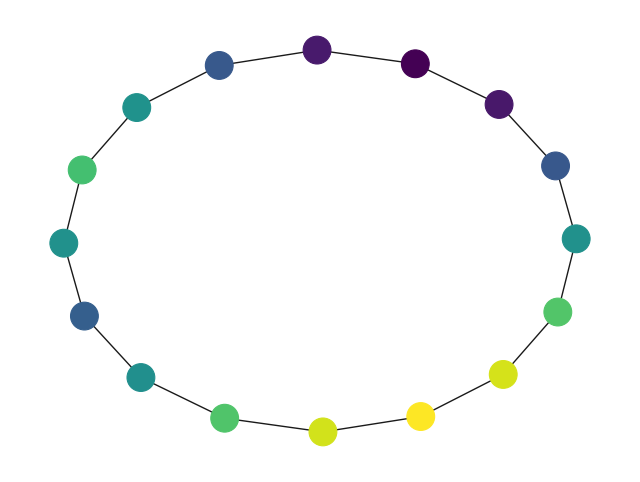

100%|██████████| 100/100

SC:0.1143161425222689
SC_norm:0.5571580712611345
TSR:0.5
SC_adj:0.5285790356305673


In [8]:
km.auto_seed()

n = 7
a = 0.0387

mapper = km.D_Mapper(verbose=0)
projected_data = mapper.fit_transform(X_data, projection=[0])
cover = km.D_Cover(n_cubes=n,alpha = a,verbose=0,tol = 12*1e-4,max_iter=3000000, n_init=100)

graph = mapper.map(projected_data, X_data, cover=cover)
interval_table_1 = cover.interval_table

color_list1 = []
for i in range(len(graph['nodes'])):
    index_list = [l for l in graph['nodes'].values()][i]
    color = np.mean(projected_data[index_list])
    color_list1.append(color)
G1 = km.adapter.to_networkx(graph) 
po = nx.kamada_kawai_layout(G1)

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw(G1, pos=po, node_color=color_list1, node_size=400, cmap='viridis', ax=ax)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(color_list1), vmax=max(color_list1)))
sm.set_array([])

plt.savefig('trefoilg.png')
plt.show()

SC_adj = evaluate.compute_SC_adj(X_data, projected_data, graph
                                 , Cover = km.D_Cover(n_cubes=n,alpha = a,verbose=0, tol = 12*1e-4,max_iter=3000000,n_init=100)
                                 , type = 'd')

